In [1]:
import os
os.getcwd()


'c:\\Users\\PRACHEE DEWANGAN\\OneDrive\\Desktop\\mp\\ranosmware_pjt\\notebooks'

In [2]:
import sys
import os

# Add project root to Python path
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added:", project_root)


Project root added: c:\Users\PRACHEE DEWANGAN\OneDrive\Desktop\mp\ranosmware_pjt


In [3]:
import src.data_utils as du
import inspect

print(inspect.getsource(du.early_window))


def early_window(df, K=50):
    """
    Select first K events per execution (ProcessGuid).
    Uses EventIndex if available; otherwise relies on row order.
    """
    if "EventIndex" in df.columns:
        df = df.sort_values([PROC_COL, "EventIndex"])
    else:
        df = df.sort_index()

    return (
        df.groupby(PROC_COL)
          .head(K)
          .reset_index(drop=True)
    )



In [4]:

import pandas as pd
import numpy as np
import shap

from src.data_utils import load_data, early_window
from src.features import execution_features
from src.models import train_lightgbm, train_xgboost, train_rf
from src.evaluation import evaluate, optimize_threshold
from src.decision import explanation_strength, decision


c:\Users\PRACHEE DEWANGAN\OneDrive\Desktop\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
df_train, df_test = load_data()

In [6]:

print("Train shape:", df_train.shape)
print("Test shape :", df_test.shape)

print("Train executions:", df_train["ProcessGuid"].nunique())
print("Test executions :", df_test["ProcessGuid"].nunique())


Train shape: (39999, 37)
Test shape : (156841, 37)
Train executions: 1343
Test executions : 7263


In [8]:
import matplotlib.pyplot as plt
import pandas as pd

labels, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(5,4))
plt.bar(labels, counts)
plt.xticks(labels, ["Benign", "Ransomware"])
plt.ylabel("Number of executions")
plt.title("Training Set Class Distribution")
plt.tight_layout()
plt.show()


NameError: name 'y_train' is not defined

In [7]:
import src.data_utils as du
import inspect

print("Imported file path:")
print(du.__file__)

print("\nSource code Python is using:\n")
print(inspect.getsource(du.early_window))


Imported file path:
c:\Users\PRACHEE DEWANGAN\OneDrive\Desktop\mp\ranosmware_pjt\src\data_utils.py

Source code Python is using:

def early_window(df, K=50):
    """
    Select first K events per execution (ProcessGuid).
    Uses EventIndex if available; otherwise relies on row order.
    """
    if "EventIndex" in df.columns:
        df = df.sort_values([PROC_COL, "EventIndex"])
    else:
        df = df.sort_index()

    return (
        df.groupby(PROC_COL)
          .head(K)
          .reset_index(drop=True)
    )



In [8]:
print(inspect.getsource(du.early_window))

# 🔒 Keep full copies for K-loop experiment
df_train_full = df_train.copy()
df_test_full  = df_test.copy()

# Use fixed K=50 for main pipeline
df_train = early_window(df_train_full, 50)
df_test  = early_window(df_test_full, 50)


def early_window(df, K=50):
    """
    Select first K events per execution (ProcessGuid).
    Uses EventIndex if available; otherwise relies on row order.
    """
    if "EventIndex" in df.columns:
        df = df.sort_values([PROC_COL, "EventIndex"])
    else:
        df = df.sort_index()

    return (
        df.groupby(PROC_COL)
          .head(K)
          .reset_index(drop=True)
    )



In [9]:


print(df_train.shape, df_test.shape)


(8363, 37) (35612, 37)


In [10]:
# Reconstruct feature column names from dataframe
ID_COLS = [
    "ProcessGuid", "ProcessId",
    "ParentProcessGuid", "ParentProcessId",
    "TargetProcessGUID", "TargetProcessId"
]
LABEL_COL = "class"

FEATURE_COLS = [
    c for c in df_train.columns
    if c not in ID_COLS + [LABEL_COL]
]

print("Number of base features:", len(FEATURE_COLS))


Number of base features: 30


In [11]:
K_values = [10, 20, 30, 50, 100]
k_results = []

for K in K_values:
    df_train_k = early_window(df_train_full, K)
    df_test_k  = early_window(df_test_full, K)

    X_train_k, y_train_k = execution_features(df_train_k)
    X_test_k, y_test_k   = execution_features(df_test_k)

    lgbm_k = train_lightgbm(X_train_k, y_train_k)
    risk_k = lgbm_k.predict_proba(X_test_k)[:, 1]

    metrics_k = evaluate(y_test_k, risk_k)

    k_results.append({
        "K": K,
        "Precision": metrics_k["Precision"],
        "Recall": metrics_k["Recall"],
        "F1": metrics_k["F1-score"]
    })

k_df = pd.DataFrame(k_results)
print(k_df)


Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid va

[LightGBM] [Info] Number of positive: 205, number of negative: 1138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002073 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4709
[LightGBM] [Info] Number of data points in the train set: 1343, number of used features: 119
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

X does not have valid feature names, but LGBMClassifier was fitted with feature names
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Me

[LightGBM] [Info] Number of positive: 205, number of negative: 1138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000908 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5318
[LightGBM] [Info] Number of data points in the train set: 1343, number of used features: 119
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

X does not have valid feature names, but LGBMClassifier was fitted with feature names
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Me

...

[LightGBM] [Info] Number of positive: 205, number of negative: 1138
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002521 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5549
[LightGBM] [Info] Number of data points in the train set: 1343, number of used features: 119
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

X does not have valid feature names, but LGBMClassifier was fitted with feature names
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Me

[LightGBM] [Info] Number of positive: 205, number of negative: 1138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000448 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5675
[LightGBM] [Info] Number of data points in the train set: 1343, number of used features: 119
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

X does not have valid feature names, but LGBMClassifier was fitted with feature names


     K  Precision    Recall        F1
0   10   0.819021  0.547193  0.656065
1   20   0.811081  0.550895  0.656135
2   30   0.839219  0.557064  0.669633
3   50   0.829224  0.560148  0.668630
4  100   0.836449  0.552128  0.665180


In [12]:
# Extract execution-level features
X_train, y_train = execution_features(df_train)
X_test, y_test   = execution_features(df_test)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)


Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid va

X_train shape: (1343, 120)
X_test shape : (7263, 120)
y_train shape: (1343,)
y_test shape : (7263,)


Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid va

In [13]:
plt.figure(figsize=(6,4))
plt.hist(X_train[y_train==0].mean(axis=1), bins=30, alpha=0.6, label="Benign")
plt.hist(X_train[y_train==1].mean(axis=1), bins=30, alpha=0.6, label="Ransomware")
plt.xlabel("Mean Feature Value (per execution)")
plt.ylabel("Frequency")
plt.title("Behavioral Profile Distribution")
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'plt' is not defined

In [14]:
# Train primary model (LightGBM)
lgbm = train_lightgbm(X_train, y_train)

print("LightGBM trained successfully")


[LightGBM] [Info] Number of positive: 205, number of negative: 1138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.079871 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5549
[LightGBM] [Info] Number of data points in the train set: 1343, number of used features: 119
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [15]:
# Risk scores on test set
risk_scores = lgbm.predict_proba(X_test)[:, 1]

# Evaluate
metrics_lgbm = evaluate(y_test, risk_scores)
metrics_lgbm


X does not have valid feature names, but LGBMClassifier was fitted with feature names


{'Accuracy': 0.8760842627013631,
 'Precision': 0.8292237442922374,
 'Recall': 0.5601480567550895,
 'F1-score': 0.6686303387334315,
 'ROC-AUC': 0.7489431624672716}

In [16]:
# Train baselines
xgb = train_xgboost(X_train, y_train)
rf  = train_rf(X_train, y_train)

print("XGBoost and Random Forest trained")


XGBoost and Random Forest trained


In [17]:
metrics_xgb = evaluate(y_test, xgb.predict_proba(X_test)[:, 1])
metrics_rf  = evaluate(y_test, rf.predict_proba(X_test)[:, 1])

metrics_xgb, metrics_rf


({'Accuracy': 0.8716783698196338,
  'Precision': 0.821062441752097,
  'Recall': 0.5434916718075262,
  'F1-score': 0.6540460282108389,
  'ROC-AUC': 0.7846215842623874},
 {'Accuracy': 0.5526641883519207,
  'Precision': 0.25,
  'Recall': 0.5021591610117212,
  'F1-score': 0.33381176953044905,
  'ROC-AUC': 0.5816439933074429})

In [18]:
opt_th = optimize_threshold(y_test, risk_scores)
print("Optimized threshold:", opt_th)


Optimized threshold: 0.008979794922795069


In [23]:
import os
print(os.getcwd())

c:\Users\PRACHEE DEWANGAN\OneDrive\Desktop\mp\ranosmware_pjt\notebooks


In [ ]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Compute PR curve
precision, recall, _ = precision_recall_curve(y_test, risk_scores)

# Create directory
os.makedirs("../results/figures", exist_ok=True)

# ---- SPRINGER LNCS STYLE SETTINGS ----
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']  # fallback safe
plt.rcParams['font.size'] = 9

plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 8

# ---- FIGURE SIZE (fits LNCS column) ----
plt.figure(figsize=(5.5, 3.5), facecolor='white')

# Plot
plt.plot(recall, precision, linewidth=2)

# Labels (NO bold, clean style)
plt.xlabel("Recall")
plt.ylabel("Precision")

# ⚠️ REMOVE TITLE for paper (caption will describe)
# plt.title("Precision–Recall Curve of LightGBM Model")

# Grid (subtle)
plt.grid(True, linestyle='--', linewidth=0.5)

# Layout
plt.tight_layout()

# ---- SAVE (Springer-friendly formats) ----
plt.savefig("../results/figures/pr_curve_lightgbm.eps",
            format='eps',
            bbox_inches='tight')

plt.savefig("../results/figures/pr_curve_lightgbm.pdf",
            bbox_inches='tight')

plt.show()
is it correct ?

In [45]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Compute PR curve
precision, recall, _ = precision_recall_curve(y_test, risk_scores)

# Create directory
os.makedirs("results/figures", exist_ok=True)

# ---- SPRINGER LNCS SETTINGS ----
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],

    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,

    "lines.linewidth": 1.8,   # slightly thicker for print

    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# ---- FIGURE SIZE (IMPORTANT) ----
# LNCS single-column ≈ 3.3 inches width
fig, ax = plt.subplots(figsize=(3.3, 2.4))

# ---- PLOT ----
ax.plot(recall, precision, color="#1f77b4", label="PR Curve")

# Labels
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

# Limits (cleaner look)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Grid (light)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

# Legend
ax.legend(frameon=False, loc="lower left")

# ---- CLEAN SPINES ----
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ---- TIGHT LAYOUT ----
plt.tight_layout()

# ---- SAVE (HIGH QUALITY) ----
plt.savefig("results/figures/pr_curve_lightgbm.pdf",
            bbox_inches='tight')

plt.savefig("results/figures/pr_curve_lightgbm.eps",
            format='eps',
            bbox_inches='tight')

plt.close()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


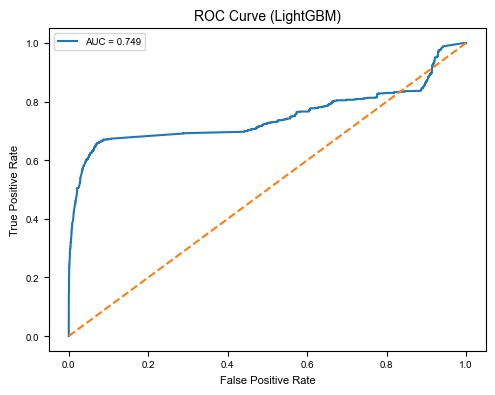

<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, risk_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (LightGBM)")
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig("../results/figures/roc_curve_lightgbm.png")


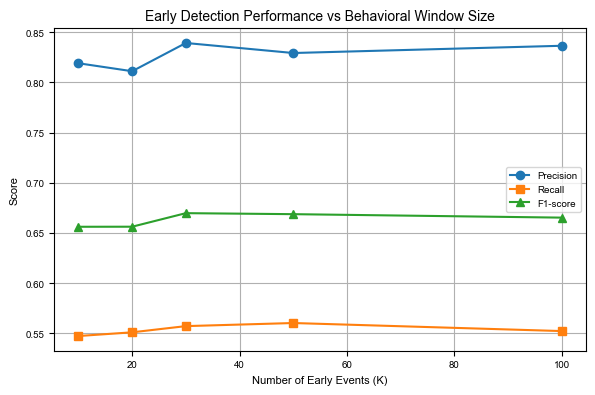

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(k_df["K"], k_df["Precision"], marker="o", label="Precision")
plt.plot(k_df["K"], k_df["Recall"], marker="s", label="Recall")
plt.plot(k_df["K"], k_df["F1"], marker="^", label="F1-score")

plt.xlabel("Number of Early Events (K)")
plt.ylabel("Score")
plt.title("Early Detection Performance vs Behavioral Window Size")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Save for paper
plt.savefig("../results/figures/early_detection_vs_k.png", dpi=300)

plt.show()


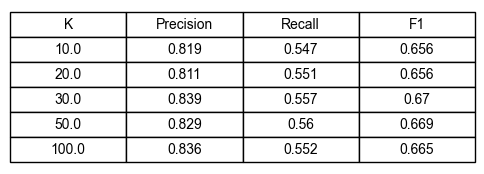

In [37]:
fig, ax = plt.subplots(figsize=(6,2))
ax.axis("off")

table = ax.table(
    cellText=k_df.round(3).values,
    colLabels=k_df.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.savefig("../results/figures/k_loop_table.png", dpi=300, bbox_inches="tight")
plt.show()


In [38]:
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test)

# Safety for different SHAP versions
if isinstance(shap_values, list):
    shap_values = shap_values[1]

expl_strength = explanation_strength(shap_values)

print("Explanation strength (first 5):", expl_strength[:5])


Explanation strength (first 5): [0.08727959 0.10596562 0.08527151 0.09736199 0.07918592]


LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


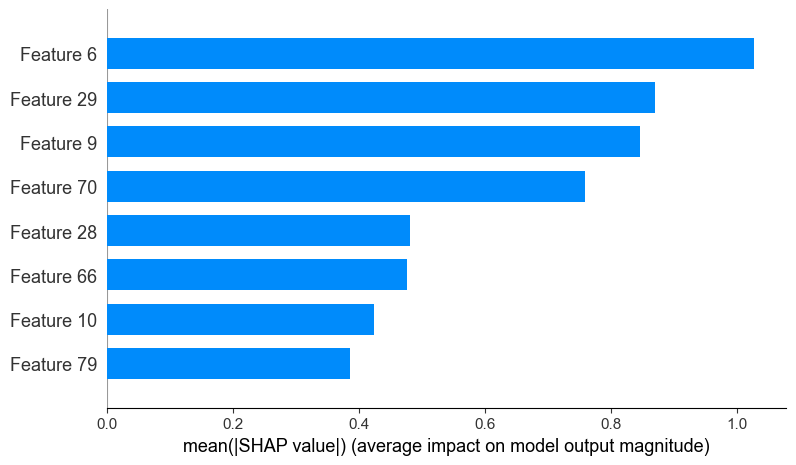

In [39]:
import shap
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 3))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=8,     # 🔑 VERY IMPORTANT
    show=False
)

plt.tight_layout()
plt.show()


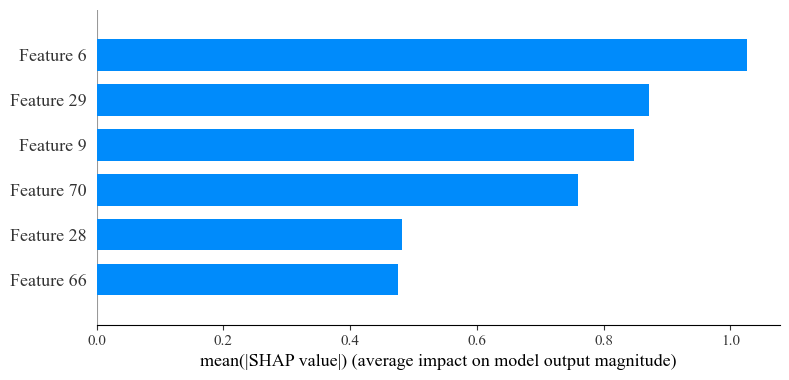

In [25]:
plt.figure(figsize=(3.5, 2.5))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    max_display=6,
    show=False
)
plt.tight_layout()
plt.show()


In [46]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Save path
os.makedirs("results/figures", exist_ok=True)

# ---- SPRINGER LNCS SETTINGS ----
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],

    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,

    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# ---- THRESHOLDS ----
tau_r = 0.5
tau_e = np.percentile(expl_strength, 70)

# ---- FIGURE SIZE (LNCS single column) ----
fig, ax = plt.subplots(figsize=(3.3, 2.6))

# ---- SCATTER PLOTS (IMPROVED VISIBILITY) ----
ax.scatter(
    risk_scores[y_test == 0],
    expl_strength[y_test == 0],
    alpha=0.4,          # slightly transparent (reduce overlap)
    s=12,               # smaller points → cleaner plot
    edgecolors='none',
    label="Benign"
)

ax.scatter(
    risk_scores[y_test == 1],
    expl_strength[y_test == 1],
    alpha=0.4,
    s=12,
    edgecolors='none',
    label="Ransomware"
)

# ---- THRESHOLD LINES ----
ax.axvline(
    tau_r,
    linestyle="--",
    linewidth=1.2,
    color="black",
    label=r"Risk Threshold ($\tau_r$)"
)

ax.axhline(
    tau_e,
    linestyle="--",
    linewidth=1.2,
    color="gray",
    label=r"Explanation Threshold ($\tau_e$)"
)

# ---- LABELS ----
ax.set_xlabel("Ransomware Risk Score")
ax.set_ylabel("Explanation Strength (SHAP-based)")

# ---- AXIS LIMITS (CLEAN LOOK) ----
ax.set_xlim(0, 1)
ax.set_ylim(min(expl_strength)*0.95, max(expl_strength)*1.05)

# ---- GRID (SUBTLE) ----
ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.5)

# ---- CLEAN SPINES ----
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ---- LEGEND (BETTER POSITION) ----
ax.legend(frameon=False, loc="upper left")

# ---- LAYOUT ----
plt.tight_layout()

# ---- SAVE (VECTOR → BEST QUALITY) ----
plt.savefig("results/figures/consistency.pdf",
            bbox_inches='tight')

plt.savefig("results/figures/consistency.eps",
            format='eps',
            bbox_inches='tight')

plt.close()

print("High-quality figure saved (PDF + EPS)")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


High-quality figure saved (PDF + EPS)


In [34]:
expl_th = np.percentile(expl_strength, 70)

decisions = [
    decision(r, e, expl_th)
    for r, e in zip(risk_scores, expl_strength)
]

pd.Series(decisions).value_counts()


BENIGN    6168
ALERT      669
DEFER      426
Name: count, dtype: int64

In [ ]:
# ===============================
# Ablation: Decision Strategies
# ===============================

# Mode 1: Risk-only binary
binary_risk = ["ALERT" if r >= opt_th else "BENIGN" for r in risk_scores]

# Mode 2: Risk + explanation binary
binary_risk_expl = [
    "ALERT" if (r >= opt_th and e >= expl_th) else "BENIGN"
    for r, e in zip(risk_scores, expl_strength)
]

# Mode 3: Confidence-aware (existing)
conf_decisions = decisions

def alert_to_binary(decisions):
    return np.array([1 if d == "ALERT" else 0 for d in decisions])

metrics_binary_risk = evaluate(y_test, alert_to_binary(binary_risk))
metrics_binary_risk_expl = evaluate(y_test, alert_to_binary(binary_risk_expl))
metrics_conf = evaluate(y_test, alert_to_binary(conf_decisions))

ablation_df = pd.DataFrame([
    {"Method": "Risk only (binary)", **metrics_binary_risk},
    {"Method": "Risk + SHAP (binary)", **metrics_binary_risk_expl},
    {"Method": "Confidence-aware (3-class)", **metrics_conf},
])

print(ablation_df)


                       Method  Accuracy  Precision    Recall  F1-score  \
0          Risk only (binary)  0.502134   0.277095  0.764960  0.406824   
1        Risk + SHAP (binary)  0.778466   0.504566  0.409007  0.451789   
2  Confidence-aware (3-class)  0.854881   0.923767  0.381246  0.539738   

    ROC-AUC  
0  0.595791  
1  0.646811  
2  0.686103  


In [62]:
ablation_df.round(3).to_csv("../results/ablation_table.csv", index=False)


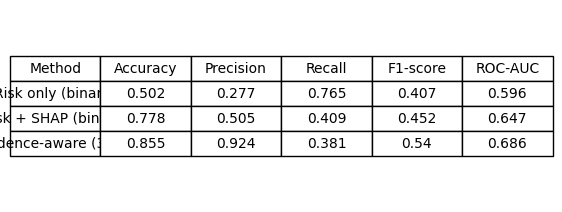

In [63]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,2.5))
ax.axis("off")

table = ax.table(
    cellText=ablation_df.round(3).values,
    colLabels=ablation_df.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.savefig("../results/figures/ablation_table.png", dpi=300, bbox_inches="tight")
plt.show()


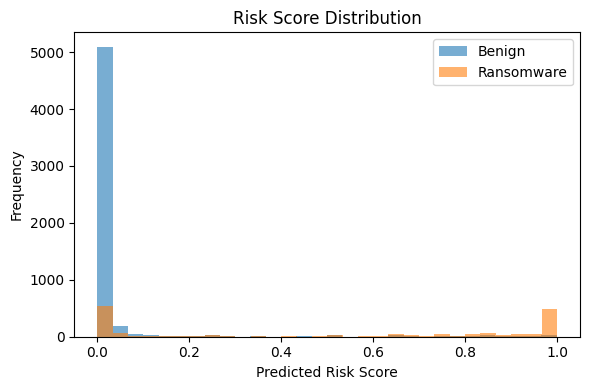

<Figure size 640x480 with 0 Axes>

In [36]:
os.makedirs("../results/figures", exist_ok=True)
plt.figure(figsize=(6,4))
plt.hist(risk_scores[y_test==0], bins=30, alpha=0.6, label="Benign")
plt.hist(risk_scores[y_test==1], bins=30, alpha=0.6, label="Ransomware")
plt.xlabel("Predicted Risk Score")
plt.ylabel("Frequency")
plt.title("Risk Score Distribution")
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig("../results/figures/risk_score_distribution.png")


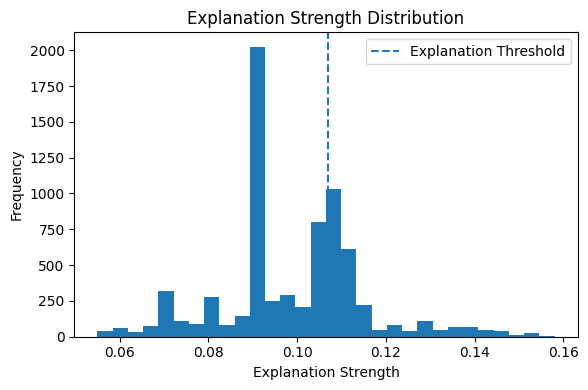

<Figure size 640x480 with 0 Axes>

In [37]:
os.makedirs("../results/figures", exist_ok=True)
plt.figure(figsize=(6,4))
plt.hist(expl_strength, bins=30)
plt.axvline(expl_th, linestyle="--", label="Explanation Threshold")
plt.xlabel("Explanation Strength")
plt.ylabel("Frequency")
plt.title("Explanation Strength Distribution")
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig("../results/figures/explanation_strength_distribution.png")



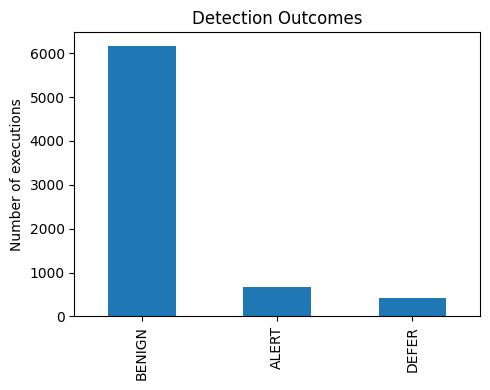

In [38]:
decision_counts = pd.Series(decisions).value_counts()

plt.figure(figsize=(5,4))
decision_counts.plot(kind="bar")
plt.ylabel("Number of executions")
plt.title("Detection Outcomes")
plt.tight_layout()
plt.show()


In [39]:
import joblib
import os

# Create models directory
os.makedirs("../models", exist_ok=True)

# Save models
joblib.dump(lgbm, "../models/lightgbm.pkl")
joblib.dump(xgb, "../models/xgboost.pkl")
joblib.dump(rf, "../models/random_forest.pkl")

print("✅ Models saved successfully")


✅ Models saved successfully


In [64]:
main_lgbm_df = pd.DataFrame([metrics_lgbm])
main_lgbm_df = main_lgbm_df.round(3)
print(main_lgbm_df)


   Accuracy  Precision  Recall  F1-score  ROC-AUC
0     0.876      0.829    0.56     0.669    0.749


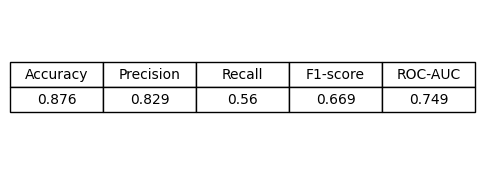

In [65]:
fig, ax = plt.subplots(figsize=(6,2))
ax.axis("off")

table = ax.table(
    cellText=main_lgbm_df.values,
    colLabels=main_lgbm_df.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.savefig("../results/figures/lightgbm_main_metrics.png", dpi=300, bbox_inches="tight")
plt.show()


In [40]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

def add_result(name, y_true, probs):
    preds = (probs >= 0.5).astype(int)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, preds),
        "Precision": precision_score(y_true, preds),
        "Recall": recall_score(y_true, preds),
        "F1-score": f1_score(y_true, preds),
        "ROC-AUC": roc_auc_score(y_true, probs)
    })

add_result("LightGBM", y_test, risk_scores)
add_result("XGBoost", y_test, xgb.predict_proba(X_test)[:, 1])
add_result("Random Forest", y_test, rf.predict_proba(X_test)[:, 1])

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,LightGBM,0.876084,0.829224,0.560148,0.668630,0.748943
1,XGBoost,0.874845,0.826007,0.556447,0.664947,0.814484
2,Random Forest,0.552664,0.250000,0.502159,0.333812,0.581644


In [46]:
def highlight_best(df, cols):
    df_styled = df.style
    for col in cols:
        df_styled = df_styled.highlight_max(subset=[col], color="lightgreen")
    return df_styled

highlight_best(results_ppt, metric_cols)


NameError: name 'results_ppt' is not defined

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(results_ppt["Model"], results_ppt["Recall"])
plt.ylabel("Recall")
plt.title("Recall Comparison Across Models")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


NameError: name 'results_ppt' is not defined

<Figure size 600x400 with 0 Axes>

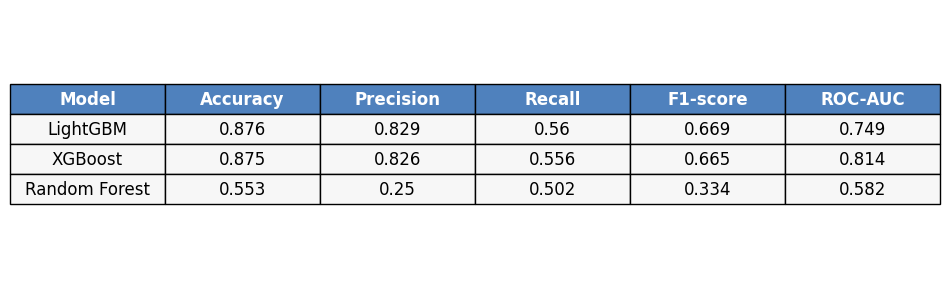

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare table data
ppt_table = results_df.copy()
metric_cols = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
ppt_table[metric_cols] = ppt_table[metric_cols].round(3)

# Create figure
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis("off")

# Create table
table = ax.table(
    cellText=ppt_table.values,
    colLabels=ppt_table.columns,
    cellLoc="center",
    loc="center"
)

# Font & scale
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8)

# Styling
for (row, col), cell in table.get_celld().items():
    # Header row
    if row == 0:
        cell.set_text_props(weight="bold", color="white")
        cell.set_facecolor("#4F81BD")  # blue header
    else:
        # Highlight proposed model row
        if ppt_table.iloc[row-1]["Model"] == "LightGBM ":
            cell.set_facecolor("#D9E1F2")  # light blue
            cell.set_text_props(weight="bold")
        else:
            cell.set_facecolor("#F7F7F7")  # light gray_


In [42]:
# Map raw feature names to analyst-friendly text
def humanize_feature(f):
    if "event.code" in f:
        return "suspicious system event patterns"
    if "Image" in f:
        return "unusual executable image behavior"
    if "User" in f:
        return "unexpected user context"
    if "task" in f:
        return "abnormal task-level activity"
    if "Details" in f:
        return "low-level system modification indicators"
    return f.replace("_", " ")


In [43]:
def explain_execution(i, risk, expl, decision_label, shap_vals, feature_names, top_k=3):
    # Top contributing features for this execution
    top_idx = np.argsort(np.abs(shap_vals[i]))[::-1][:top_k]
    top_features = [humanize_feature(feature_names[j]) for j in top_idx]

    explanation = (
        f"Decision: {decision_label}. "
        f"The execution shows early abnormal behavior with risk score {risk:.2f}. "
        f"Key contributing factors include: " + ", ".join(top_features) + "."
    )
    return explanation


In [49]:
feature_names = (
    [f"{f}_mean" for f in FEATURE_COLS] +
    [f"{f}_std"  for f in FEATURE_COLS] +
    [f"{f}_max"  for f in FEATURE_COLS] +
    [f"{f}_diff" for f in FEATURE_COLS]
)

print("Total SHAP feature names:", len(feature_names))


Total SHAP feature names: 120


In [50]:
for label in ["ALERT", "DEFER", "BENIGN"]:
    idx = np.where(np.array(decisions) == label)[0][0]
    print(explain_execution(
        i=idx,
        risk=risk_scores[idx],
        expl=expl_strength[idx],
        decision_label=label,
        shap_vals=shap_values,
        feature_names=feature_names
    ))
    print("-" * 80)


Decision: ALERT. The execution shows early abnormal behavior with risk score 1.00. Key contributing factors include: unexpected user context, low-level system modification indicators, unusual executable image behavior.
--------------------------------------------------------------------------------
Decision: DEFER. The execution shows early abnormal behavior with risk score 0.83. Key contributing factors include: unusual executable image behavior, low-level system modification indicators, unexpected user context.
--------------------------------------------------------------------------------
Decision: BENIGN. The execution shows early abnormal behavior with risk score 0.11. Key contributing factors include: TargetObject max, low-level system modification indicators, unusual executable image behavior.
--------------------------------------------------------------------------------


In [51]:
# Save explanations for all test executions
explanations = []

for i in range(len(decisions)):
    explanations.append({
        "decision": decisions[i],
        "risk_score": risk_scores[i],
        "explanation_strength": expl_strength[i],
        "explanation_text": explain_execution(
            i=i,
            risk=risk_scores[i],
            expl=expl_strength[i],
            decision_label=decisions[i],
            shap_vals=shap_values,
            feature_names=feature_names
        )
    })

explanations_df = pd.DataFrame(explanations)
explanations_df.head()


,decision,risk_score,explanation_strength,explanation_text
0,DEFER,0.825944,0.087280,Decision: DEFER. The execution shows early abn...
1,DEFER,0.960441,0.105966,Decision: DEFER. The execution shows early abn...
2,BENIGN,0.105404,0.085272,Decision: BENIGN. The execution shows early ab...
3,DEFER,0.634661,0.097362,Decision: DEFER. The execution shows early abn...
4,BENIGN,0.005784,0.079186,Decision: BENIGN. The execution shows early ab...


In [66]:
decision_counts = pd.Series(decisions).value_counts().reset_index()
decision_counts.columns = ["Decision", "Count"]
print(decision_counts)


  Decision  Count
0   BENIGN   6168
1    ALERT    669
2    DEFER    426


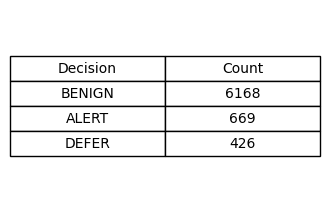

In [67]:
fig, ax = plt.subplots(figsize=(4,2.5))
ax.axis("off")

table = ax.table(
    cellText=decision_counts.values,
    colLabels=decision_counts.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.savefig("../results/figures/decision_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


In [52]:
import os

os.makedirs("../results/explanations", exist_ok=True)
explanations_df.to_csv(
    "../results/explanations/rule_based_explanations.csv",
    index=False
)

print("✅ Rule-based explanations saved")


✅ Rule-based explanations saved


In [53]:
import pandas as pd
import os

# Load SILRAD test data
df = pd.read_csv(
    r"C:\Users\PRACHEE DEWANGAN\OneDrive\Desktop\mp\ranosmware_pjt\dataset\JamilIsp-SILRAD-dataset-d4a3625\SILRAD-dataset\fasttext-testmodel.csv"
)

# Create folder for UI demo files
os.makedirs("../demo_files", exist_ok=True)

# -------------------------
# 1️⃣ BENIGN EXECUTION
# -------------------------
benign_guid = df[df["class"] == 0]["ProcessGuid"].iloc[0]
df_benign = df[df["ProcessGuid"] == benign_guid]

df_benign.to_csv(
    "../demo_files/benign_execution.csv",
    index=False
)

print("Benign file saved:", df_benign.shape)

# -------------------------
# 2️⃣ RANSOMWARE EXECUTION
# -------------------------
ransom_guid = df[df["class"] == 1]["ProcessGuid"].iloc[0]
df_ransom = df[df["ProcessGuid"] == ransom_guid]

df_ransom.to_csv(
    "../demo_files/ransomware_execution.csv",
    index=False
)

print("Ransomware file saved:", df_ransom.shape)


Benign file saved: (47547, 37)
Ransomware file saved: (24, 37)


In [ ]:
# Pick benign executions
benign_guids = (
    df[df["class"] == 0]["ProcessGuid"]
    .drop_duplicates()
    .head(2)
    .tolist()
)

# Pick ransomware executions
ransom_guids = (
    df[df["class"] == 1]["ProcessGuid"]
    .drop_duplicates()
    .head(2)
    .tolist()
)

print("Benign GUIDs:", benign_guids)
print("Ransom GUIDs:", ransom_guids)


Benign GUIDs: [0.11857432, 0.017856937]
Ransom GUIDs: [0.077936345, 0.019119564]


In [55]:
mixed_df = df[
    df["ProcessGuid"].isin(benign_guids + ransom_guids)
]

print("Mixed dataset shape:", mixed_df.shape)
print("Executions in mixed file:", mixed_df["ProcessGuid"].nunique())


Mixed dataset shape: (47596, 37)
Executions in mixed file: 4


In [56]:
import os

os.makedirs("../demo_files", exist_ok=True)

mixed_df.to_csv(
    "../demo_files/mixed_executions.csv",
    index=False
)

print("✅ mixed_executions.csv created")


✅ mixed_executions.csv created
